# FORGE walkthrough: Credit Default, LightGBM, seed 11

This notebook runs FORGE step by step on the UCI *Default of Credit Card Clients* data and ends with the
published test AP of **0.5502016**. Each step names the paper section it implements, states the rule in one
or two lines, calls the corresponding function in `src/forge`, and prints the intermediate result.

The R0 LLM proposals are **replayed** from `assets/credit_default_r0_proposals.json`, so no LLM is called.
Everything else (materialisation, screening, admission, validation, experts, rebuild and test evaluation)
is recomputed here. `python main.py` runs the same pipeline in one call.

In [1]:
import sys, logging
from pathlib import Path
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "forge").is_dir())
sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import average_precision_score

from forge import make_config, llm
from forge.data import split_dataset, validation_blocks, validation_halves
from forge.datasets import load_dataset
from forge.features import Surface
from forge.learners import fit_oof
from forge.screening import screen_candidates, psi, adversarial_auc
from forge.admission import shadow_admission
from forge.validation import ValidationBudget, harm_only_gate, choose_configuration
from forge.scoring import score_pool, admission_threshold
from forge.pipeline import initialize_state, routing_rule, fit_core, run_experts, freeze_and_evaluate

pd.set_option("display.width", 140)
pd.set_option("display.max_colwidth", 60)
cfg = make_config("credit_default", seed=11)      # configs/default.yaml + configs/datasets/credit_default.yaml
{k: cfg[k] for k in ("dataset", "learner", "seed", "oof_folds", "llm_mode")} | {"lightgbm": cfg["lightgbm"]}

{'dataset': 'credit_default',
 'learner': 'lightgbm',
 'seed': 11,
 'oof_folds': 4,
 'llm_mode': 'replay',
 'lightgbm': {'n_estimators': 400,
  'learning_rate': 0.05,
  'num_leaves': 63,
  'min_child_samples': 20,
  'subsample': 0.8,
  'colsample_bytree': 0.8}}

## 1. Data partitioning — paper "Data Partitioning"

$D = I_{64\%} \oplus V_{16\%} \oplus T_{20\%}$. Credit Default has no reliable event time, so a fixed-seed
stratified split is used (80/20, then 80/20 of the first part). The test labels go into a `TestVault`
that can be opened exactly once, at the very end.

In [2]:
raw = load_dataset(cfg)            # downloads the official UCI archive into data/ on first use
part = split_dataset(raw, cfg)
I, V, Vx = part.I, part.V, part.V.drop(columns=cfg["label"])
y_V = V[cfg["label"]].to_numpy(np.int8)
print(raw.shape)
pd.DataFrame(part.class_balance)

(30000, 25)


,split,rows,positives,positive_rate
0,I,19200,4247,0.221198
1,V,4800,1062,0.221250
2,T,6000,1327,0.221167


### Two views of V — Eq. (1) and the S2 halves

S1 uses three contiguous, single-use blocks $V=\mathcal V_1\oplus\mathcal V_2\oplus\mathcal V_3$ (3:1:1);
each round that changes the configuration consumes the next block. S2 uses the two halves $V_1, V_2$.

In [3]:
blocks = validation_blocks(len(V), cfg["validation_block_weights"])
halves = validation_halves(len(V))
print("S1 blocks :", [(int(b[0]), int(b[-1]) + 1, len(b), int(y_V[b].sum())) for b in blocks], "(start, end, rows, positives)")
print("S2 halves :", [(int(h[0]), int(h[-1]) + 1, len(h), int(y_V[h].sum())) for h in halves])

S1 blocks : [(0, 2880, 2880, 648), (2880, 3840, 960, 194), (3840, 4800, 960, 220)] (start, end, rows, positives)
S2 halves : [(0, 2400, 2400, 540), (2400, 4800, 2400, 522)]


## 2. Baseline (Raw) and OOF residuals — Eq. (2)

$I=F_1\oplus\dots\oplus F_4$, $\hat p_i=\hat f^{(-k)}(x_i)$ for $i\in F_k$, and $r_i=y_i-\hat p_i$.
The V prediction is the mean of the four fold models.

In [4]:
baseline = initialize_state(I, Vx, cfg)
y_I = I[cfg["label"]].to_numpy()
residual = y_I - baseline["oof"]
print("base columns:", len(baseline["columns"]), baseline["columns"][:8], "...")
print(f"OOF AP on I = {baseline['oof_ap']:.4f}   AP on V = {average_precision_score(y_V, baseline['V_prediction']):.4f}")
print(f"residual: mean {residual.mean():+.4f}, mean |r| {np.abs(residual).mean():.4f}")

base columns: 29 ['limit_bal', 'education', 'marriage', 'age', 'pay_0', 'pay_2', 'pay_3', 'pay_4'] ...
OOF AP on I = 0.5370   AP on V = 0.5630
residual: mean +0.0152, mean |r| 0.2507


## 3. Routing rule — S1.2 "Routing"

Before search, a fixed routing rule decides which parts of S1 run. R0 is skipped when more than 20% of the raw
columns shift between I and V (Eq. (8) for numeric columns, unseen-category rate above 20% for categorical
columns). CoF is skipped only when no such shift is detected, the dataset has no event-time column, and no
feature of the fixed entity-history library reaches τ. Credit Default has no shift, no event time and no entity
column, so **R0 runs and CoF is skipped**, as in the paper's experiments.

In [5]:
router = routing_rule(baseline, V, cfg)
print({k: router[k] for k in ("shift", "ratio", "tau", "has_event_time", "run_r0", "run_cof")})
router["drift"].sort_values("psi", ascending=False).head(6)

{'shift': False, 'ratio': 0.0, 'tau': 0.02523981261475093, 'has_event_time': False, 'run_r0': True, 'run_cof': False}


,feature,psi,adv_auc,novelty,drifted
4,age,0.004111,0.503574,None,False
22,pay_amt6,0.003927,0.494987,None,False
16,bill_amt6,0.003166,0.498536,None,False
21,pay_amt5,0.002645,0.498200,None,False
20,pay_amt4,0.002533,0.498671,None,False
0,limit_bal,0.002500,0.500777,None,False


## 4. S1.1.1 Candidate proposal (R0)

R0 makes five free-form LLM calls (unary, binary, ternary, related-column, complement); the LLM only sees
the dataset name, the learner type and column names, missing rates and cardinalities; the complement call also
sees the ten most important columns and twelve most co-used column pairs of a 150-tree probe model. Here the recorded proposals are replayed. This is the
prompt that the `unary` call would send:

In [6]:
prompt = llm.build_prompt("free_form", baseline, cfg, family="unary")
print(prompt[:700], "...")

You propose features; FORGE alone decides admission. Propose up to 8 unary numeric pointwise features. Return only schema JSON. No labels, predictions, external state, I/O, aggregates, groupby, rolling or apply. Expressions may use df['column'], basic arithmetic, np.abs/maximum/minimum/log1p/sqrt/clip/where and pd.to_numeric. Guard divisions/logs/square roots. Each feature transforms one column. Evidence:
{"dataset": "credit_default", "learner": "lightgbm", "columns": [{"name": "limit_bal", "missing_rate": 0.0, "n_unique": 80}, {"name": "education", "missing_rate": 0.0, "n_unique": 7}, {"name": "marriage", "missing_rate": 0.0, "n_unique": 4}, {"name": "age", "missing_rate": 0.0, "n_unique":  ...


In [7]:
proposal = llm.propose_r0(baseline, cfg)
print(proposal["audit"])
props = pd.DataFrame([{"name": k, "family": v["family"], "expression": v["expression"]}
                      for k, v in proposal["specs"].items()])
print(len(props), "proposals")
props.head(10)

[{'source': 'frozen_llm_proposals', 'model': 'gpt-5.5', 'calls': 5, 'sha256': '22f39769e002b1e85ab4fee58b138799bf418ca36d4641b67d8fe6d63ca0d1bb'}]
34 proposals


,name,family,expression
0,free1_limit_bal_log,unary_monotone_log,"np.log1p(np.maximum(pd.to_numeric(df['limit_bal'], error..."
1,free1_age_sqrt_over_20,unary_monotone_reshape,"np.sqrt(np.maximum(pd.to_numeric(df['age'], errors='coer..."
2,free1_pay_0_positive_delay_log,unary_monotone_log,"np.log1p(np.maximum(pd.to_numeric(df['pay_0'], errors='c..."
3,free1_pay_2_positive_delay_log,unary_monotone_log,"np.log1p(np.maximum(pd.to_numeric(df['pay_2'], errors='c..."
4,free1_pay_3_positive_delay_log,unary_monotone_log,"np.log1p(np.maximum(pd.to_numeric(df['pay_3'], errors='c..."
5,free1_pay_0_oof_te_logit,unary_bounded_rescaling,np.log((np.minimum(np.maximum(pd.to_numeric(df['pay_0_oo...
6,free2_bill_amt1_limit_util,guarded_ratio,"pd.to_numeric(df['bill_amt1'], errors='coerce') / (pd.to..."
7,free2_bill_amt1_over_bill_amt2_growth,guarded_ratio,"(pd.to_numeric(df['bill_amt1'], errors='coerce') - pd.to..."
8,free2_pay_amt1_bill_amt2_coverage,guarded_ratio,"pd.to_numeric(df['pay_amt1'], errors='coerce') / (np.max..."
9,free2_pay_amt2_bill_amt3_coverage,guarded_ratio,"pd.to_numeric(df['pay_amt2'], errors='coerce') / (np.max..."


### Safe materialisation

Each expression is parsed and whitelisted (only `df['col']`, arithmetic, a few element-wise NumPy/pandas
functions; no label, no I/O, no aggregation) and then evaluated on I and V. Invalid or constant candidates
are dropped.

In [8]:
valid, validity = llm.validate_proposals(proposal["specs"], baseline["surface"], cfg,
                                        limit=cfg["max_initial_candidates"])   # proposal budget: 36 valid
print(f"{len(valid)} of {len(proposal['specs'])} proposals are valid")
pd.DataFrame(validity).query("not valid")

34 of 34 proposals are valid


,feature,valid,reason


## 5. S1.1.2 Stability screening — Eqs. (5), (6), (7), (8)

$\mathrm{PSI}_c=\sum_b (p_{V,b}-p_{I,b})\log(p_{V,b}/p_{I,b})$ on I-deciles, and
$\mathrm{AdvAUC}_c=U_c/(n_I n_V)$ with $U_c=R_{V,c}-n_V(n_V+1)/2$.
A candidate passes iff $\mathrm{PSI}_c\le0.25$ and $|\mathrm{AdvAUC}_c-0.5|\le0.15$. No labels are used.

In [9]:
pool = dict(valid)
surface = Surface(I, Vx, baseline["surface"].plan, pool, cfg)
screened, screen = screen_candidates(surface, list(valid), cfg)
dropped = [n for n in valid if n not in screened]
print(f"{len(screened)} kept, dropped: {dropped}")
screen.sort_values("psi", ascending=False).head(5)

33 kept, dropped: ['free1_pay_0_oof_te_logit']


,feature,psi,adv_auc,kept
5,free1_pay_0_oof_te_logit,3.989207,0.531033,False
13,free2_pay0_te_age_te_product,0.019618,0.499666,True
20,free3_pay_amt1_log_vs_pay0_te_freq,0.005029,0.498873,True
1,free1_age_sqrt_over_20,0.004111,0.503574,True
17,free3_bill1_minus_pay1_limit_share,0.003415,0.502330,True


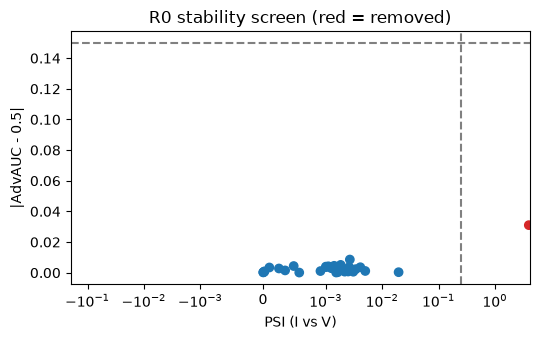

In [10]:
fig, ax = plt.subplots(figsize=(5.5, 3.5))
ax.scatter(screen["psi"], (screen["adv_auc"] - .5).abs(), c=np.where(screen["kept"], "tab:blue", "tab:red"))
ax.axvline(cfg["psi_max"], ls="--", c="gray"); ax.axhline(cfg["advauc_band"], ls="--", c="gray")
ax.set_xscale("symlog", linthresh=1e-3); ax.set_xlabel("PSI (I vs V)"); ax.set_ylabel("|AdvAUC - 0.5|")
ax.set_title("R0 stability screen (red = removed)"); plt.tight_layout(); plt.show()

## 6. S1.1.3 Admission (R0): shadow permutation importance — Eqs. (9), (11)

Every screened candidate gets a shuffled shadow copy. PI is the drop in OOF AP when a column is permuted at
prediction time (fold models fixed). On each half $J\in\{I_a,I_b\}$ of I,
$\theta^J=\max_{c^*\in\mathcal S}\mathrm{PI}^J(c^*)$, and $c$ is admitted iff
$\mathrm{PI}^{I_a}(c)>\theta^{I_a}$ and $\mathrm{PI}^{I_b}(c)>\theta^{I_b}$.

In [11]:
admitted, admission = shadow_admission(surface, screened, baseline["columns"], cfg)
print("admitted:", admitted)
admission.sort_values("pi_1", ascending=False).head(8)

admitted: ['free2_pay0_te_age_te_product', 'free3_pay0_age_limit_norm', 'free4_pay_delay_positive_hhi', 'free5_pay_delay_tail_burden']


,feature,pi_1,pi_2,theta_1,theta_2,kept
15,free3_pay0_age_limit_norm,0.044964,0.035007,0.003677,0.001906,True
12,free2_pay0_te_age_te_product,0.028247,0.025549,0.003677,0.001906,True
21,free4_pay_delay_positive_hhi,0.014972,0.016436,0.003677,0.001906,True
27,free5_pay_delay_tail_burden,0.009497,0.011993,0.003677,0.001906,True
22,free4_bill_amount_share_entropy,0.002940,0.002020,0.003677,0.001906,False
19,free3_pay_amt1_log_vs_pay0_te_freq,0.002785,0.002005,0.003677,0.001906,False
23,free4_pay_amount_log_cv,0.002336,0.002827,0.003677,0.001906,False
18,free3_bill2_pay2_limit_stress,0.002280,0.001597,0.003677,0.001906,False


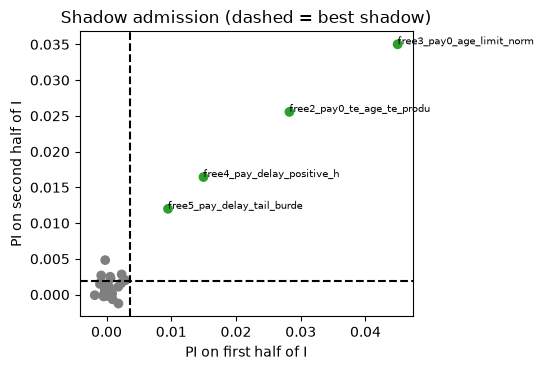

In [12]:
fig, ax = plt.subplots(figsize=(5.5, 3.8))
ax.scatter(admission["pi_1"], admission["pi_2"], c=np.where(admission["kept"], "tab:green", "tab:gray"))
ax.axvline(admission["theta_1"].iloc[0], ls="--", c="k"); ax.axhline(admission["theta_2"].iloc[0], ls="--", c="k")
for _, r in admission[admission["kept"]].iterrows():
    ax.annotate(r["feature"][:26], (r["pi_1"], r["pi_2"]), fontsize=7)
ax.set_xlabel("PI on first half of I"); ax.set_ylabel("PI on second half of I")
ax.set_title("Shadow admission (dashed = best shadow)"); plt.tight_layout(); plt.show()

## 7. S1.2 Round validation: harm-only gate — Eq. (14)

R0 changed the configuration, so it consumes block $\mathcal V_1$ and is checked on both halves of it.
For each region $h$: $\Delta_h=\mathrm{AP}_h(C')-\mathrm{AP}_h(C)$, $\mathrm{SE}_h$ from 1,000 paired
bootstrap replicates, and the update passes iff $\Delta_h\ge-2\,\mathrm{SE}_h$ for every $h$.

In [13]:
budget = ValidationBudget(len(V), cfg)
block_id, regions = budget.next_regions(initial_round=True)
columns = list(dict.fromkeys(baseline["columns"] + admitted))
fitted = fit_oof(surface, columns)
passed, gate = harm_only_gate(y_V, baseline["V_prediction"], fitted["apply"], regions, cfg)
print(f"block {block_id}: regions of {[len(r) for r in regions]} rows -> accepted = {passed}")
gate[["region", "rows", "positives", "base_ap", "candidate_ap", "delta", "se", "threshold", "accepted"]]

block 1: regions of [1440, 1440] rows -> accepted = True


,region,rows,positives,base_ap,candidate_ap,delta,se,threshold,accepted
0,1,1440,351,0.604208,0.598403,-0.005805,0.006358,-0.012716,True
1,2,1440,297,0.525842,0.529421,0.003579,0.007591,-0.015181,True


In [14]:
r0_state = {"surface": surface, "columns": columns, "features": list(admitted), "oof": fitted["oof"],
            "V_prediction": fitted["apply"], "oof_ap": fitted["oof_ap"]}
accepted = [baseline] + ([r0_state] if passed else [])
print(f"OOF AP on I: baseline {baseline['oof_ap']:.4f} -> R0 {r0_state['oof_ap']:.4f}")

OOF AP on I: baseline 0.5370 -> R0 0.5387


## 8. CoF residual score — Eqs. (3), (4), (12)

In a CoF round, candidates are scored against the current OOF residual after removing the part predictable
from the current features with a five-fold Ridge: $\tilde g_i=g_i-\hat g_i^{(-k)}$,
$S(g)=\mathrm{corr}(\tilde g, r)$, and a candidate may enter when $|S(g)|\ge\tau=z_{0.95}/\sqrt{n_I^+}$.
The routing rule skips CoF on Credit Default, so the scores below are **illustrative only** (they do not
influence the result): they score the R0 pool against the residual of the new configuration.

In [15]:
tau = admission_threshold(int(y_I.sum()), cfg["entry_alpha"])
scores = pd.DataFrame(score_pool(r0_state, {k: pool[k] for k in pool if k not in admitted}, cfg))
scores["abs"] = scores["score"].abs()
print(f"tau = {tau:.4f}; candidates with |S| >= tau: {(scores['abs'] >= tau).sum()}")
scores.sort_values("abs", ascending=False).head(6)

tau = 0.0252; candidates with |S| >= tau: 0


,feature,family,score,abs
8,free2_pay_amt1_bill_amt2_coverage,guarded_ratio,0.009281,0.009281
29,free5_demographic_status_risk_blend,low_gain_interaction,0.008914,0.008914
18,free3_pay_amt1_log_vs_pay0_te_freq,ternary_two_way_normalization,0.007710,0.007710
20,free4_bill_amount_share_entropy,row_series_shape,0.006078,0.006078
2,free1_pay_0_positive_delay_log,unary_monotone_log,0.005222,0.005222
9,free2_pay_amt2_bill_amt3_coverage,guarded_ratio,-0.005136,0.005136


## 9. CoF core selection — S1.2

Among the baseline and the accepted configurations, the one with the highest AP on the complete V is fixed as
the CoF core and passed to S2.

In [16]:
final, selection = choose_configuration(accepted, y_V, cfg)
print("selected features:", final["features"])
selection

selected features: ['free2_pay0_te_age_te_product', 'free3_pay0_age_limit_norm', 'free4_pay_delay_positive_hhi', 'free5_pay_delay_tail_burden']


,configuration,features,V_ap,selected
0,0,0,0.562966,False
1,1,4,0.564540,True


## 10. S2 Optional experts — Sec. IV-D

The fixed CoF core is fitted by stratified four-fold on $I\oplus V$; its out-of-fold predictions
$\hat p_{\mathrm{core}}^{\mathrm{OOF}}$ are used for the residual slices, for weight selection and as the initial
prediction on V (the same fit gives the rebuilt core of S3). S2.1 builds target-encoding experts (purely
categorical columns; none here), residual-slice experts (subgroups with lift
$L(Q)>\max(\sqrt{n_I^+/n_Q^+},1.15)$, Eq. (17)) and recency experts (time-ordered data only). S2.2 picks $w^*$
on held-out predictions in I (Eq. (24)) and accepts an expert only if
$\Delta_{V_1}\ge\mathrm{SE}_{V_1}$ and $\Delta_{V_2}\ge\mathrm{SE}_{V_2}$ (Eq. (28)).

In [17]:
core = fit_core(final, part, pool, cfg)                      # four-fold fit on I+V
s2_state = {**final, "oof": core["oof_I"], "V_prediction": core["oof_V"]}
experts = run_experts(s2_state, V, pool, dropped, cfg)
sl = pd.DataFrame(experts["candidates"]["slice"])
print("TE candidates     :", sum(r["kept"] for r in experts["candidates"]["te"]))
print("slice rules tested:", len(sl), "| passed:", int(sl["passed"].sum()))
print("recency           :", experts["candidates"]["recency"][0]["reason"])
print("accepted experts  :", [e.spec["name"] for e in experts["experts"]])
sl.dropna(subset=["lift"]).sort_values("lift", ascending=False)[["column", "rule", "coverage", "positives", "lift", "lift_threshold", "passed"]].head(5)

TE candidates     : 0
slice rules tested: 138 | passed: 0
recency           : no event time; recency experts are not used
accepted experts  : []


,column,rule,coverage,positives,lift,lift_threshold,passed
30,pay_2,value,0.131823,1402,1.650667,1.740472,False
47,pay_4,value,0.105885,1069,1.613721,1.993206,False
24,pay_0,value,0.125104,816,1.606151,2.281372,False
39,pay_3,value,0.127292,1259,1.600475,1.836658,False
55,pay_5,value,0.087083,905,1.584476,2.166291,False


## 11. S3 Final reconstruction and evaluation — Sec. IV-E

All decisions are frozen. The rebuilt core averages the four fold models of the stratified four-fold fit on
$I\oplus V$ (from `fit_core` above) to predict T; accepted experts (none here) would be applied without
refitting. Only then is the vault opened, once, for all prediction vectors.

In [18]:
test_scores, predictions, frozen = freeze_and_evaluate(final, baseline, core, part, experts, cfg)
paper_ap = 0.5502016                            # published test AP, LightGBM seed 11
table = pd.DataFrame(test_scores).T
table["paper (seed 11)"] = [np.nan, paper_ap, np.nan]
table

,ap,roc_auc,paper (seed 11)
baseline,0.548259,0.774307,NaN
cof,0.550202,0.772667,0.550202
cof_experts,0.550202,0.772667,NaN


In [19]:
diff = abs(test_scores["cof"]["ap"] - paper_ap)
print(f"FORGE test AP = {test_scores['cof']['ap']:.16f}; published = {paper_ap}; |diff| = {diff:.1e}")
assert diff < 1e-6
print("frozen features:", list(frozen["features"]))

FORGE test AP = 0.5502016247535624; published = 0.5502016; |diff| = 2.5e-08
frozen features: ['free2_pay0_te_age_te_product', 'free3_pay0_age_limit_norm', 'free4_pay_delay_positive_hhi', 'free5_pay_delay_tail_burden']


## Where to go next

* `python main.py --dataset temporal_demo` runs a synthetic time-ordered dataset on which the routing rule
  enables the CoF rounds (template proposal and expansion, depth contract, greedy entry, trailing-window check,
  permutation exit, block consumption, stop after two unchanged rounds).
* `python main.py --llm-command "..."` (any LLM command-line tool) or `--llm-mode api` (an OpenAI-compatible
  endpoint) replaces the recorded proposals with a live LLM; see README.
* The paper's results are in its Tables 5-9.